In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data = data.drop(['customerID'], axis = 1)

In [6]:
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
data[data['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
data[data['tenure']==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [9]:
data.groupby(data['TotalCharges'].isna())['Churn'].value_counts(normalize=True)

TotalCharges  Churn
False         No       0.734215
              Yes      0.265785
True          No       1.000000
Name: proportion, dtype: float64

In [10]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)
data['Is_a_new_customer'] = (data['TotalCharges']==0).astype(int)

*Все пропущенные значения в TotalCharges соответствуют клиентам со стажем = 0.
Мы не заполняем эти значения, чтобы избежать внесения искусственных закономерностей.*

*Можно или удалить строки где tenure = 0  и соответсвенно TotalCharges = 0, тогда мы должны понимать что предсказываем отток клиентов только после 1 месяца сотрудничесва с ними, или создаем флаг Is_a_new_customer, тогда можно предсказыать отток сразу, но исходя из данных все новые клиеты не уходят в первый месяц, что может оказаться ложью на деле. Я использую 2й вариант, так как хочу обучить модель использую все данные.*

In [11]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
data[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


Visualization


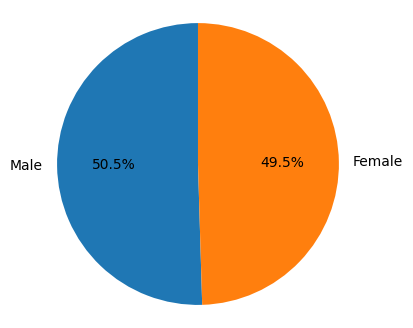

In [12]:
gender_counts = data['gender'].value_counts()

plt.figure(figsize=(4, 4))


plt.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90,
)

plt.axis('equal')
plt.show()

*Кол-во мужчин и женщин одинаковое*

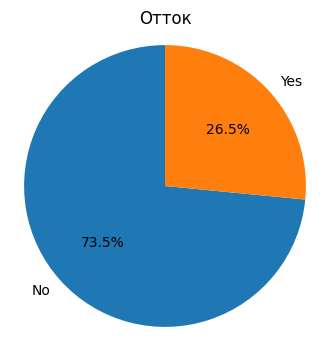

In [13]:
churn_counts = data['Churn'].value_counts()
plt.figure(figsize=(4, 4))


plt.pie(churn_counts.values,
        labels=churn_counts.index,
        autopct='%1.1f%%',
        startangle=90,
)
plt.title('Отток')
plt.axis('equal')
plt.show()

*Дисбаланс целевого класса*


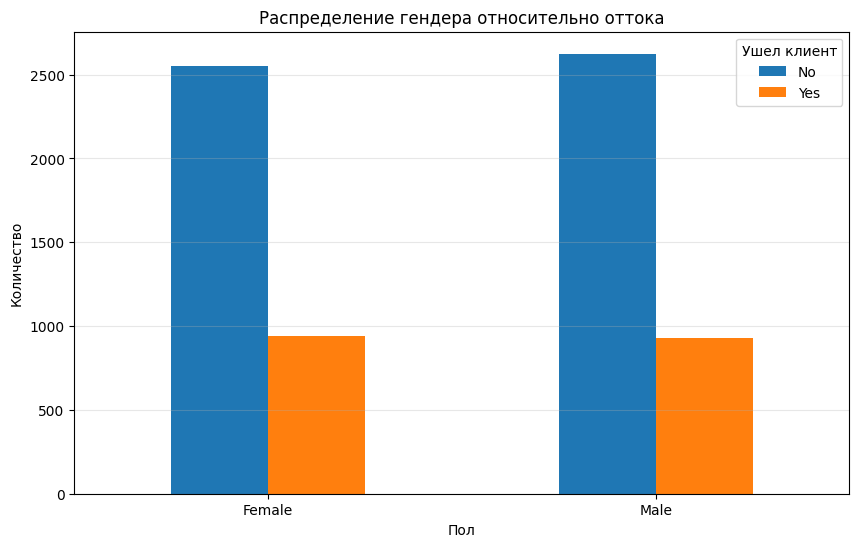

In [14]:
cross_tab_gen = pd.crosstab(data['gender'], data['Churn'])

cross_tab_gen.plot(kind='bar', figsize=(10, 6))
plt.title('Распределение гендера относительно оттока')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.legend(title='Ушел клиент')
plt.grid(axis='y', alpha=0.3)
plt.show()

*Пол не влияет на отток*


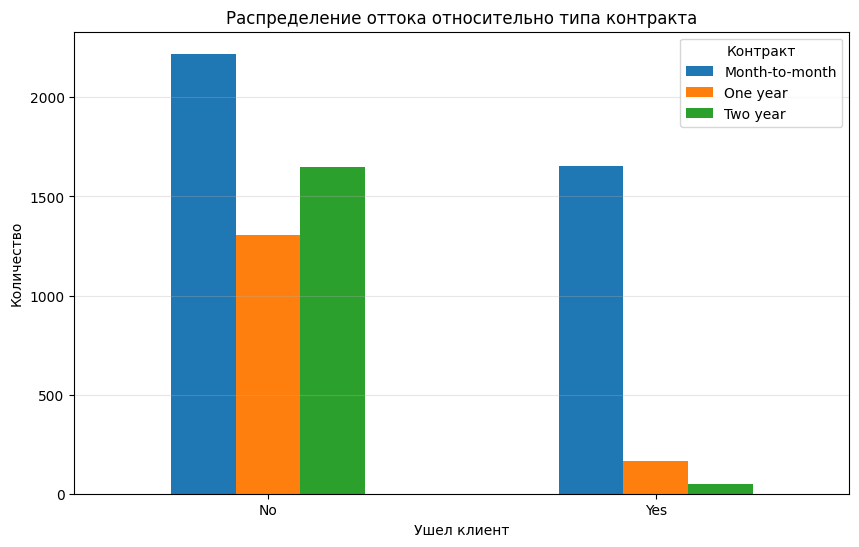

In [15]:
cross_tab_chrn = pd.crosstab(data['Churn'], data['Contract'])

cross_tab_chrn.plot(kind='bar',figsize=(10,6))
plt.title('Распределение оттока относительно типа контракта')
plt.xlabel('Ушел клиент')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.legend(title='Контракт')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [16]:
churn_rate_contract = (
    data
    .groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
)

churn_rate_contract

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

*Около 75% клиентов с помесячным контрактом решили отказаться от услуг по сравнению с 13% клиентов с годовым контрактом и 3% с двухлетним контрактом.*
**Тип контракта является сильным прогностическим фактором.**


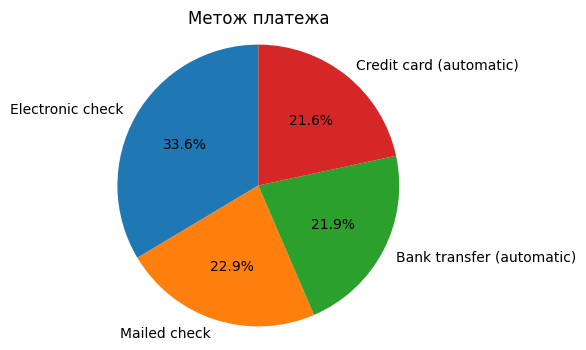

In [17]:
payment_count = data['PaymentMethod'].value_counts()
plt.figure(figsize=(4, 4))


plt.pie(payment_count.values,
        labels=payment_count.index,
        autopct='%1.1f%%',
        startangle=90,
)
plt.title('Метож платежа')
plt.axis('equal')
plt.show()

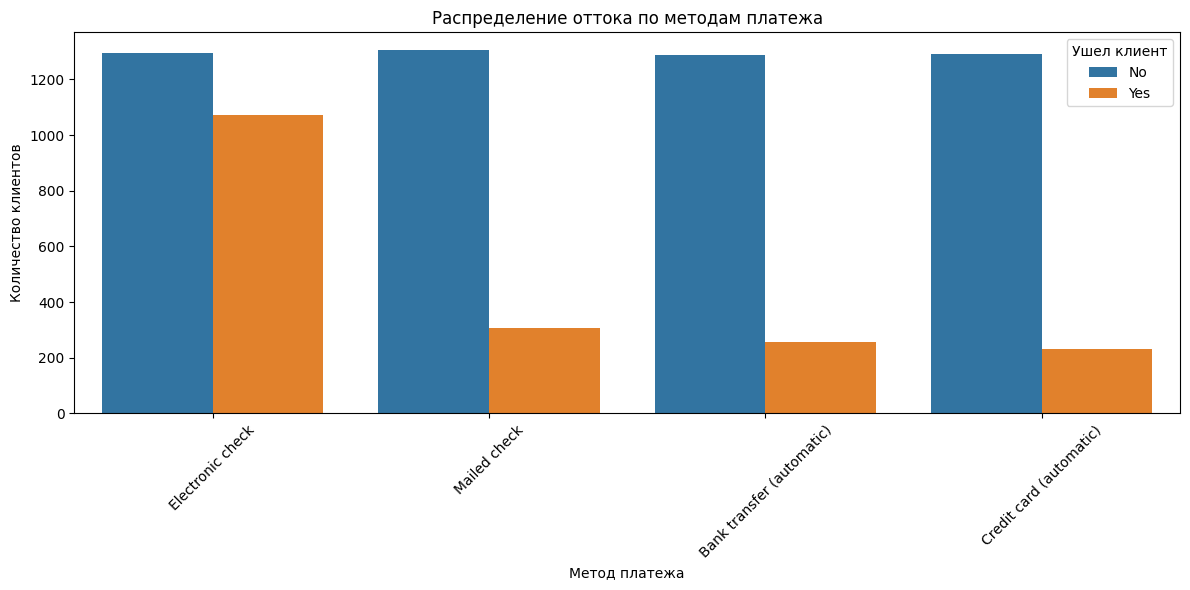

In [18]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='PaymentMethod', hue='Churn')
plt.title('Распределение оттока по методам платежа')
plt.xlabel('Метод платежа')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45)
plt.legend(title='Ушел клиент')
plt.tight_layout()
plt.show()


*Большинство клиентов, съехавших из квартиры, использовали электронные чеки в качестве способа оплаты.
Клиенты, выбравшие автоматический перевод на кредитную карту или автоматический банковский перевод и отправку чека по почте, реже съезжали.*

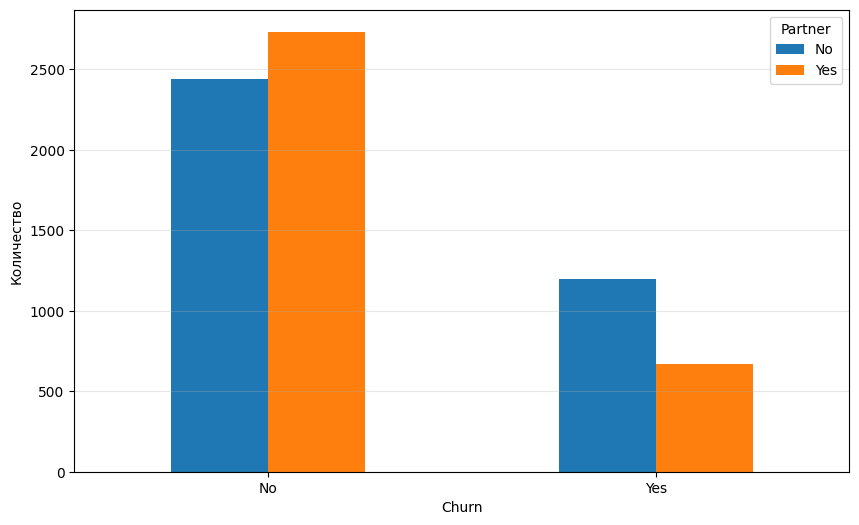

In [19]:
cross_tab_partners = pd.crosstab(data['Churn'], data['Partner'] )

cross_tab_partners.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

*Клиенты без партнера чаще уходят.*


<Axes: xlabel='Churn', ylabel='count'>

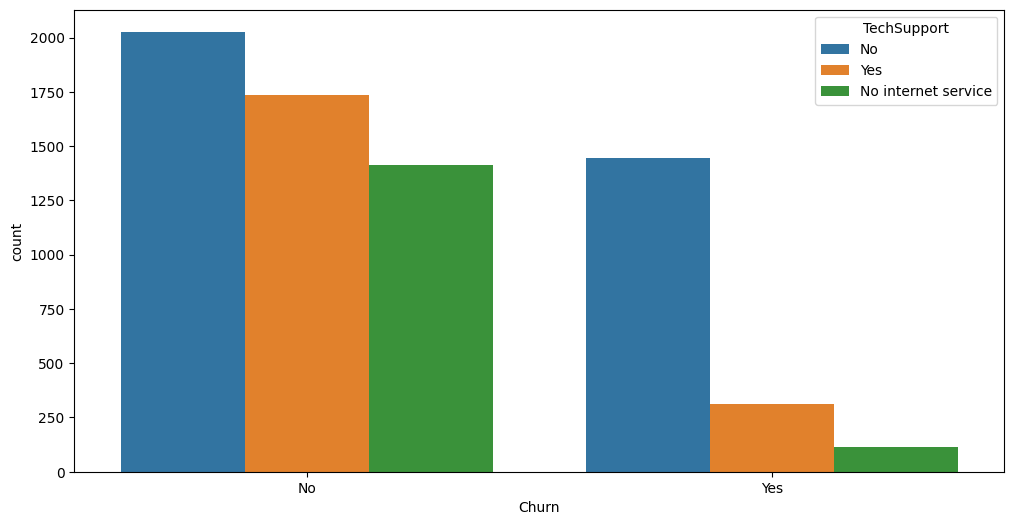

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='Churn', hue='TechSupport')

*Клиенты, у которых нет технической поддержки, скорее всего, перейдут к другому поставщику услуг.*


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

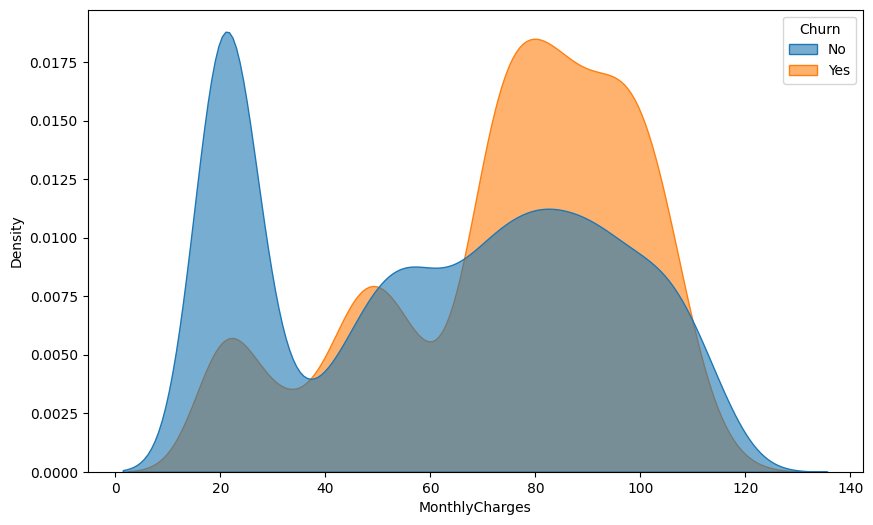

In [21]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=data,               
    x='MonthlyCharges',      
    hue='Churn',             
    fill=True,
    alpha=0.6,
    common_norm=False        
)

In [50]:
data.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


*Клиенты с более высокими ежемесячными платежами также более склонны к оттоку.Оптимальная ежемесечная плата составляет примено 70*

C:\Users\Север\AppData\Local\Temp\ipykernel_11040\1206359969.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


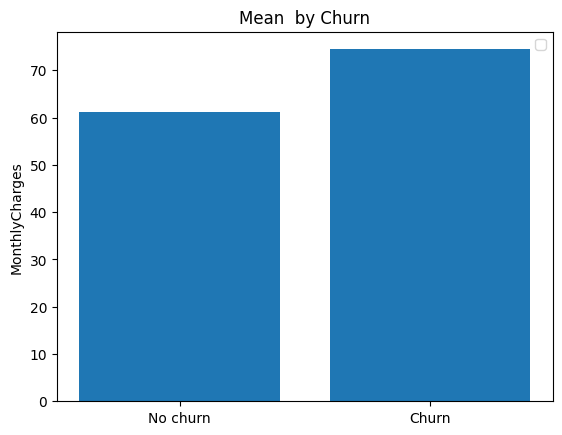

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

agg = (
    data.groupby("Churn")["MonthlyCharges"]
    .agg(["mean"])
    .reset_index()
)

agg["Churn"] = agg["Churn"].map({0: "No churn", 1: "Churn"})

plt.figure()

plt.bar(agg["Churn"], agg["mean"])
plt.title("Mean  by Churn")
plt.ylabel("MonthlyCharges")
plt.legend()
plt.show()

*Большая цена влияет на отток клиентов*

<Axes: >

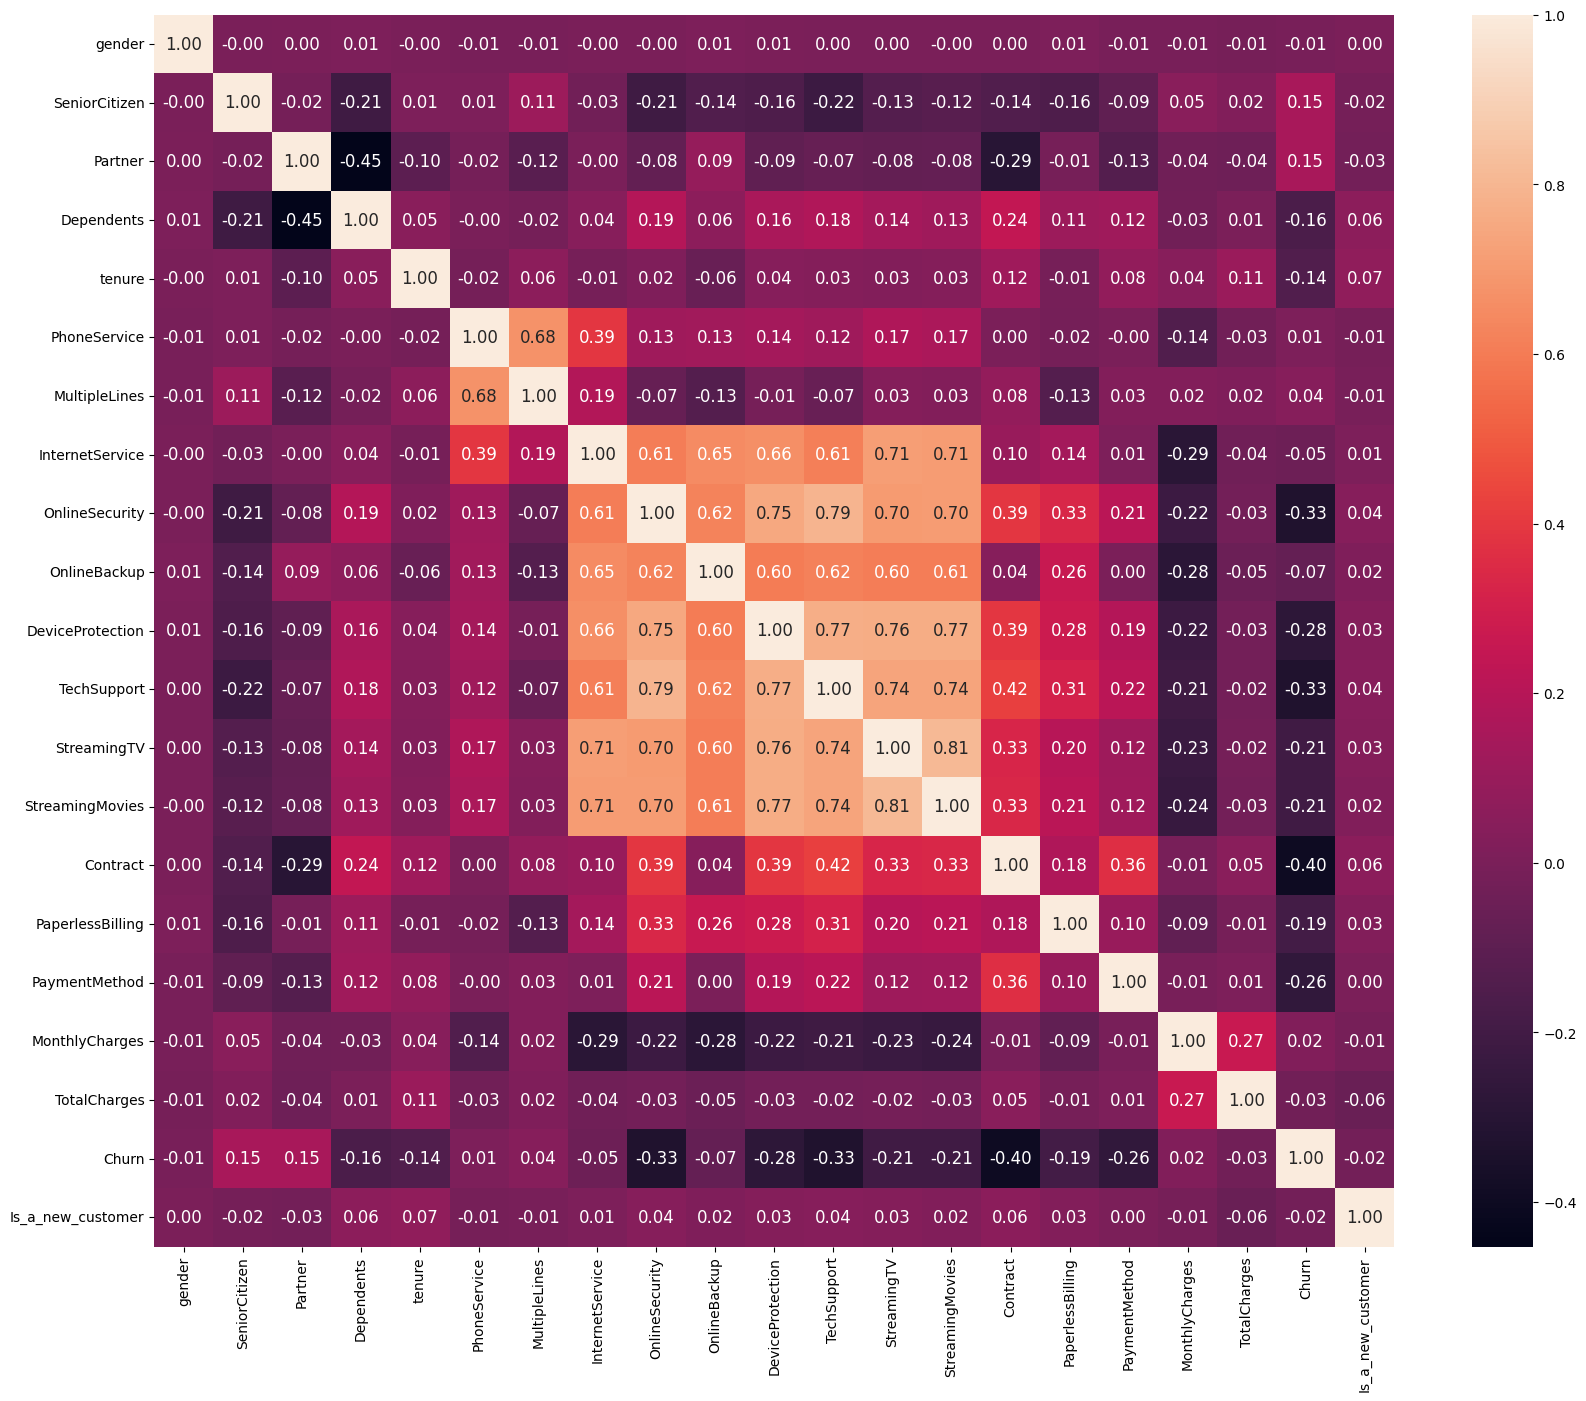

In [24]:
plt.figure(figsize=(20, 16))

corr = data.apply(lambda x: pd.factorize(x)[0]).corr()
sns.heatmap(corr,
            fmt='.2f',
            annot=True,
            annot_kws={'size': 12})

Бинарные характеристики, связанные с услугами, демонстрируют сильную попарную корреляцию (~0,7),
указывающую на избыточность и предполагающую, что они могут представлять собой общий базовый фактор,
связанный с принятием услуг.

In [51]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Is_a_new_customer
0,0,0,1,0,1,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0,0
1,1,0,0,0,34,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0,0
2,1,0,0,0,2,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1,0
3,1,0,0,0,45,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0,0
4,0,0,0,0,2,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0,0
7039,0,0,1,1,72,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0,0
7040,0,0,1,1,11,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0,0
7041,1,1,1,0,4,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1,0


*Набор данных содержит 7043 клиента с 21 характеристикой.
Целевая переменная «Отток клиентов» является бинарной и несбалансированной.
InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV и StreamingMovies коррелируют между собой.*

Вывод

## Выводы из разведочного анализа данных

1. Набор данных содержит информацию на уровне клиентов, включающую как числовые, так и категориальные характеристики,
описывающие контракты, услуги и поведение при выставлении счетов.

2. Целевая переменная (отток клиентов) умеренно несбалансирована, с существенно меньшей долей
клиентов, которые ушли, по сравнению с теми, кто не ушел.
Следовательно, accuracy не является надежным самостоятельным показателем для оценки модели.

3. Тип контракта является наиболее влиятельным фактором, связанным с оттоком.
Клиенты с ежемесячными контрактами уходят значительно чаще, чем клиенты с контрактами на один или два года.

4. Характеристики, связанные с выставлением счетов, демонстрируют сильную связь с оттоком.
Более высокие ежемесячные платежи и использование электронного чека в качестве способа оплаты связаны с повышенным риском оттока.

5. Характеристики, связанные с услугами, по отдельности дают ограниченный сигнал,
но в совокупности указывают на то, что клиенты с меньшим количеством пакетных услуг с большей вероятностью уходят.

6. Несколько числовых переменных (tenure, TotalCharges) демонстрируют асимметричное распределение и содержат выбросы,
что указывает на необходимость масштабирования или применения надежных методов предварительной обработки.

7. Наблюдаются сильные корреляции между несколькими бинарными признаками, связанными с услугами,
что указывает на потенциальные проблемы мультиколлинеарности для линейных моделей.

8. В целом, разведочный анализ подтверждает, что данные содержат значимые закономерности, связанные с оттоком клиентов.